<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>


# **Non-Negative Matrix Factorization**


## **Introduction**
**Non-Negative Matrix Factorization (NMF)** is an unsupervised learning method that breaks a non-negative data matrix into two smaller non-negative matrices. The image above shows the core idea:

$$
V \approx WH
$$

Here, $V$ is the original data matrix. The matrix $W$ contains learned basis components, or latent features. The matrix $H$ contains non-negative coefficients that describe how strongly each component is used.

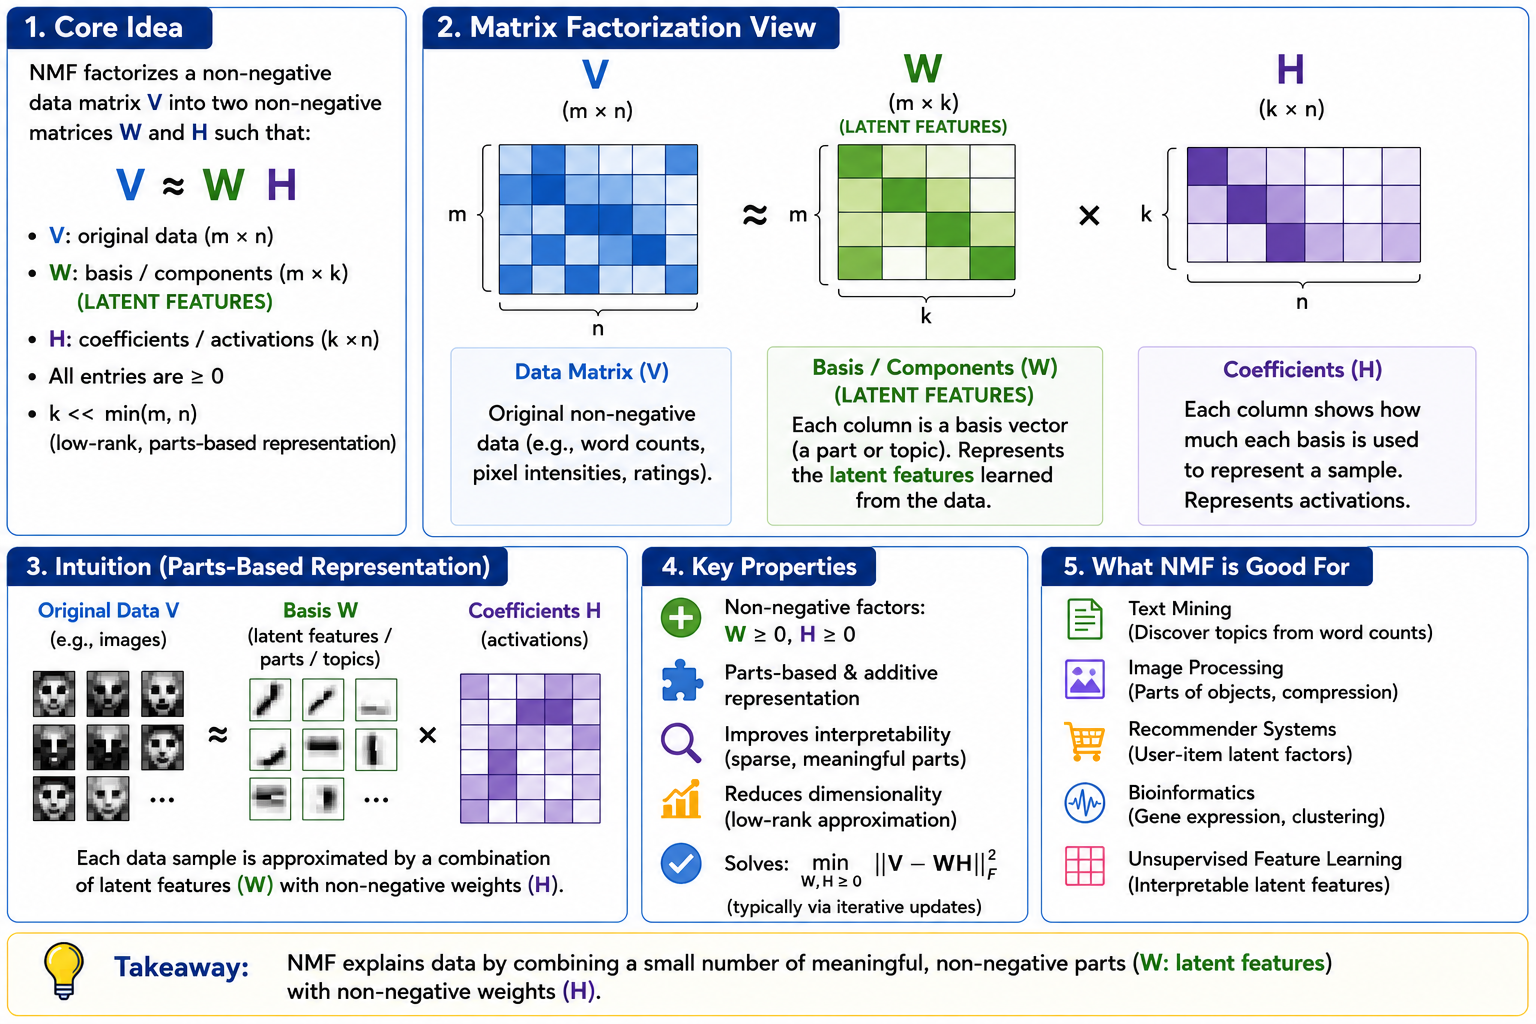

For image data, this has a useful interpretation. NMF learns visual parts, such as edges, shadows, or face regions, and each image is represented as an additive combination of those parts. Because all values are non-negative, the model builds images by adding parts together instead of subtracting parts away. This makes the result easier to interpret.

The image also highlights common uses of NMF, including text mining, image processing, recommender systems, bioinformatics, and unsupervised feature learning. In this lab, we will use NMF for image retrieval and interpret the learned components as visual patterns.


### **Project Scenario**

You have been hired by a video streaming platform that specializes in children's content. The company wants to make sure that the content on its platform does not infringe on copyrighted visual material. It has created an image database of copyrighted material, and it needs a system that can detect both identical images and visually similar images.

Your task is to build an image retrieval system that finds the most similar database image for each image in the provided dataset. Because the model may be used for legal review, it must be interpretable. In other words, it should help explain why two images are considered similar.

NMF is a good fit for this task because it represents each image using learned visual parts and their non-negative weights. If two images use similar parts with similar weights, they are likely to be visually similar. This makes the retrieval result easier to inspect than a black-box similarity score alone.

This lab uses the [Anime Face Dataset](https://www.kaggle.com/datasets/splcher/animefacedataset?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) from Kaggle.


### **Workflow**

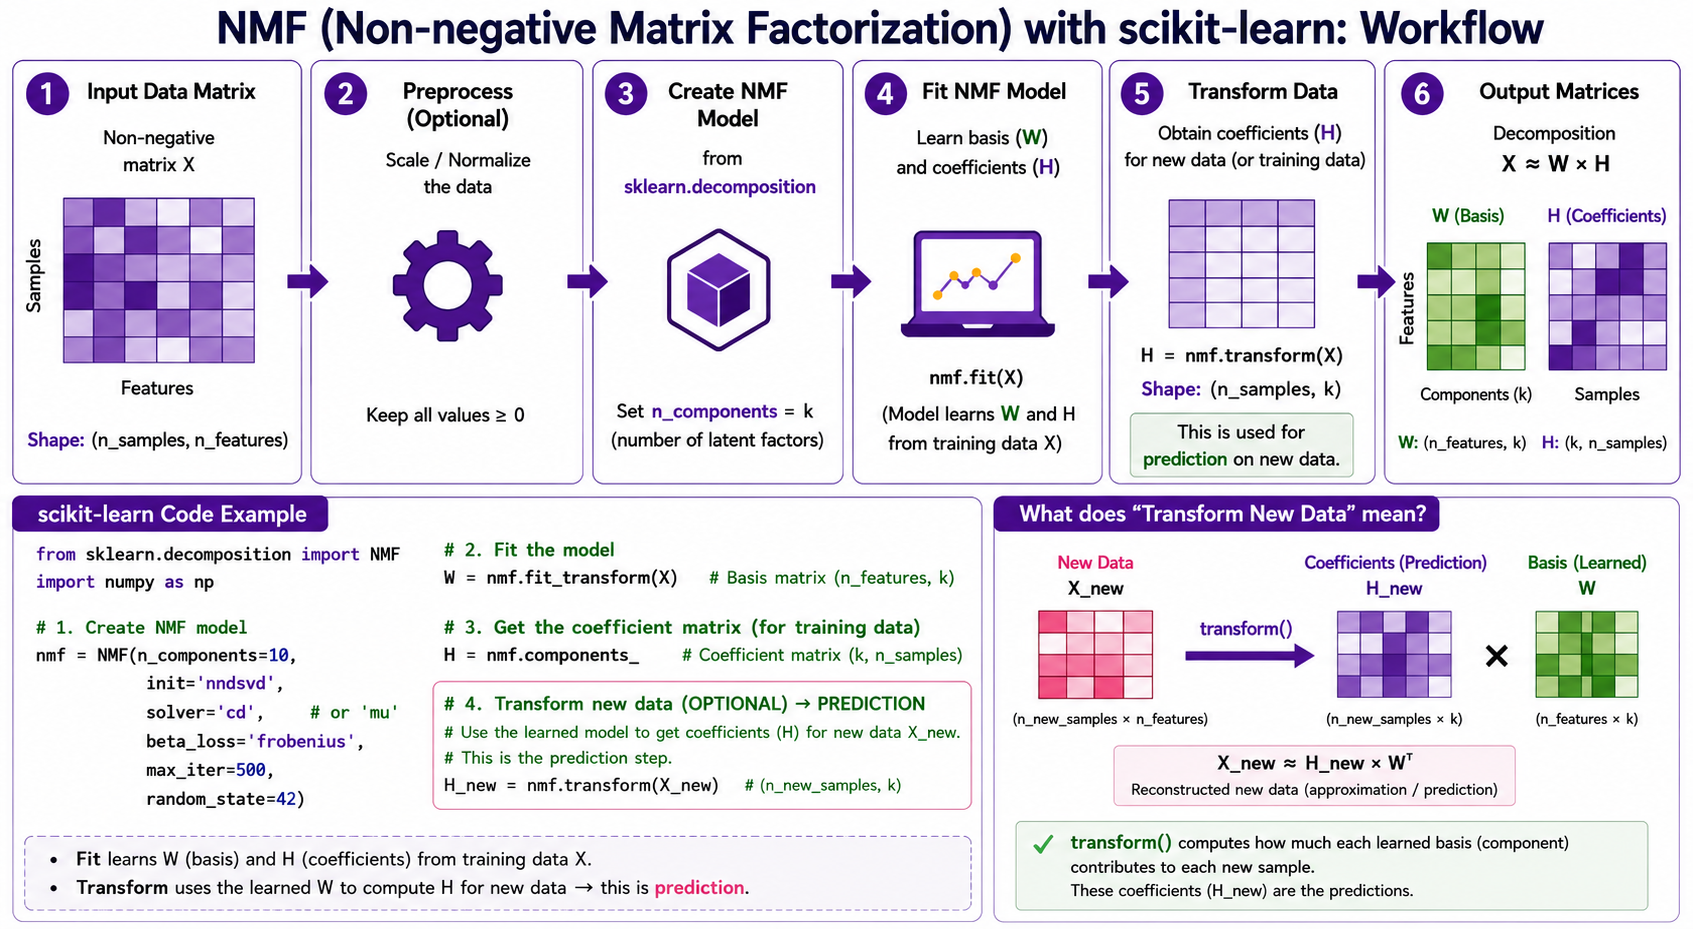

The workflow image above shows how NMF is applied with scikit-learn. First, we start with a non-negative input data matrix $X$, where rows are samples and columns are features. For images, each row can be a flattened image, and each feature can be a pixel value.

Next, we may preprocess the data, but all values must remain non-negative. Then we create an `NMF` model and choose `n_components = k`, which controls the number of latent parts to learn. After fitting the model, NMF learns basis components and coefficients so that the original data can be approximated by their product.

The `fit_transform(X)` step gives the low-dimensional coefficients for the training images. The learned components can be accessed from the fitted model. For new images, `transform(X_new)` uses the learned basis components to compute new coefficient vectors. These coefficient vectors can then be compared to find visually similar images.


## __Table of Contents__

1. [Objectives](<#Objectives>)
2. [Datasets](<#Datasets>)
3. [Setup](<#Setup>)
    1. [Installing required libraries](<#Installing-required-libraries>)
    2. [Importing Required Libraries](<#Importing-Required-Libraries>)
    3. [Defining Helper Functions](<#Defining-Helper-Functions>)
4. [Background](<#Background>)
    1. [What is Non-Negative Matrix Factorization?](<#What-is-Non-Negative-Matrix-Factorization?>)
5. [Applying Non-Negative Matrix Factorization](<#Applying-Non-Negative-Matrix-Factorization>)
    1. [Reconstructing Images Using `inverse_transform`](<#Reconstructing-Images-Using-inverse_transform>)
6. [Image Retrieval System](<#Image-Retrieval-System>)
    1. [1. Core Concept: Latent Space Matching](<#1.-Core-Concept:-Latent-Space-Matching>)
    2. [2. Understanding the Distance Matrix](<#2.-Understanding-the-Distance-Matrix>)
7. [Exercises](<#Exercises>)
    1. [Exercise 1](<#Exercise-1>)
    2. [Exercise 2](<#Exercise-2>)
    3. [Exercise 3](<#Exercise-3>)
    4. [Exercise 4](<#Exercise-4>)


## **Objectives**

After completing this lab, you will be able to:

- **Understand** the basic idea behind Non-Negative Matrix Factorization.
- **Explain** how NMF decomposes a data matrix into basis components and coefficients.
- **Apply** NMF to image data using scikit-learn.
- **Use** NMF encodings to retrieve visually similar images.
- **Interpret** NMF components as image parts.


***


## **Datasets**

Download and unzip the **images** dataset: 


In [65]:
import skillsnetwork

await skillsnetwork.prepare(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/images/images.tar.gz"
)

FileExistsError: Error: File '/home/wusu/Documents/Coursera/IBM_machine_learning/Unsupervised Machine Learning/Course_4_Unsupervised_Machine_Learning/images' already exists.
If you want to overwrite any existing files, use prepare(..., overwrite=True).

## **Setup**


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for mathematical operations.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for visualizing the data.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for machine learning and machine-learning-pipeline related functions.


### **Installing required libraries**


The required modules are pre-installed in the Skills Network Labs environment. If you run this notebook in a different Jupyter environment, such as Watson Studio or Anaconda, install the libraries by removing the `#` before `!mamba` in the code cell below.


In [ ]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

You can use <a href="https://www.sympy.org/en/index.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01">SymPy</a> to print matrices in a readable format.


In [ ]:
#!conda install -c anaconda sympy -y

### **Importing Required Libraries**

_We recommend you import all required libraries in one place (here):_


In [ ]:
import warnings

warnings.simplefilter("ignore")

import logging
import numpy as np
import pandas as pd
from numpy.random import RandomState
import matplotlib.pyplot as plt


from sklearn.decomposition import NMF


from os import listdir, getcwd
from os.path import isfile, join
from PIL import Image, ImageOps
import os

### **Defining Helper Functions**


Load the training and test sets:


In [ ]:
def get_data_matrix(test=False, Length=100, Width=100, mypath="images/"):

    files = [
        join(mypath, f)
        for f in listdir(mypath)
        if isfile(join(mypath, f)) and f[0] != "."
    ]
    if mypath + "/.DS_Store" in files:
        files.remove(mypath + "/.DS_Store")

    if test:
        print("test data")
        files = files[9000:10000]

    else:
        print("training data")
        files = files[0:9000]

    print(len(files))
    X = np.zeros((len(files), Length * Width))
    for i, file in enumerate(files):
        img = Image.open(file).resize((Width, Length))
        img = ImageOps.grayscale(img)

        I = np.array(img)

        X[i, :] = I.reshape(1, -1)
    return X

Plot image vectors:


In [ ]:
def reshape_row(x):
    plt.imshow(x.reshape(Length, Width), cmap="gray")

This threshold function returns the indices where the input `similar_distance` is greater than `min_` and less than `max_`.


In [ ]:
def threshold(similar_distance, max_=0.1, min_=0):
    dataset_index = np.where(
        np.logical_and(similar_distance > min_, similar_distance < max_)
    )[0]
    query_index = similar_index[
        np.logical_and(similar_distance > min_, similar_distance < max_)
    ]
    return dataset_index, query_index

Plot dataset images and query images. `X` and `X_q` are global variables.


In [ ]:
def plot_data_query(dataset_index, query_index, N):
    for data_sample, query_sample in zip(dataset_index[0:N], query_index[0:N]):

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        reshape_row(X[data_sample])
        plt.title("dataset sample {}".format(data_sample))
        plt.subplot(1, 2, 2)
        reshape_row(X_q[query_sample])
        plt.title("query sample match {}".format(query_sample))
        plt.show()

        print("-----------------------------------------------------")

## **Background**


### **What is Non-Negative Matrix Factorization?**

**Non-Negative Matrix Factorization (NMF)** is a dimensionality reduction and unsupervised learning method. It factorizes a high-dimensional non-negative matrix into two lower-rank non-negative matrices.

The key constraint is that **all values must be non-negative**. This makes the result easier to interpret because the original data is reconstructed by adding parts together rather than by subtracting one part from another.

**Mathematical Formulation**

Given an input data matrix $\mathbf{X}$ with shape $N \times D$:

- $N$ is the number of samples, such as individual images.
- $D$ is the number of features, such as flattened pixel values.
- Every element satisfies $X_{ij} \ge 0$.

NMF tries to find an approximate factorization:

$$\mathbf{X} \approx \mathbf{\hat{X}} = \mathbf{W}\mathbf{H}$$

The matrices have these dimensions:

- $\mathbf{X}$ is an $N \times D$ matrix containing the original data.
- $\mathbf{W}$ is an $N \times r$ matrix containing the weights or encodings.
- $\mathbf{H}$ is an $r \times D$ matrix containing the basis components.
- $r$ is the chosen number of components, where $r \ll \min(N, D)$.

**Physical Interpretation of the Matrices**

When NMF is applied to images, the two factorized matrices have useful interpretations:

1. **Basis matrix ($\mathbf{H}$):** Each row of $\mathbf{H}$ represents a basic visual pattern, or a "basis image," learned from the dataset. Examples may include edges, eyes, hair shapes, or nose shapes.
2. **Encoding matrix ($\mathbf{W}$):** Each row of $\mathbf{W}$ represents one image. The values in that row show how strongly each basis image contributes to reconstructing the original image.

A reconstructed image $\mathbf{\hat{x}}_i$ is a non-negative weighted combination of the basis rows:

$$\mathbf{\hat{x}}_i = \sum_{k=1}^{r} W_{ik} \mathbf{h}_k$$

Here, $\mathbf{h}_k$ is the $k$-th row of $\mathbf{H}$, and $W_{ik}$ is its weight for image $i$.


## **Applying Non-Negative Matrix Factorization**


**Image retrieval** is the process of searching and retrieving images from a large digital database. In this lab, the goal is to find identical or visually similar animated faces in the dataset so they can be reviewed for possible copyright infringement.


First, we represent the image collection as a data matrix $\mathbf{X}$. Each row is a flattened $100 \times 100$ grayscale image vector, so each image has $D = 10,000$ features.


In [ ]:
Length, Width = 100, 100
X = get_data_matrix(test=False, Length=100, Width=100, mypath="images")
X.shape

training data
9000


(9000, 10000)

We can use `sklearn.decomposition.NMF` to decompose the data matrix into two non-negative matrices, $\mathbf{W}$ and $\mathbf{H}$. Their dot product approximates the original matrix $\mathbf{X}$:

$$\mathbf{X} \approx \mathbf{W}\mathbf{H}$$

**Key Parameters in scikit-learn's NMF**

When creating an `NMF` model in scikit-learn, we can set several hyperparameters that control the decomposition and optimization process:

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| **`n_components`** | `int` | *None* | Number of latent components or basis features ($r$) to keep. |
| **`tol`** | `float` | `1e-4` | Stopping tolerance. The algorithm stops when the relative change in the loss function is below this value. |
| **`max_iter`** | `int` | `200` | Maximum number of optimization iterations. |

---


Set the target number of components to $r = 10$. This creates a reduced-dimensional representation of the images.


In [ ]:
n_components = 10

Next, create the NMF model and fit it to the image data matrix $X$ to learn the basis images and their weights.


In [ ]:
nmf_estimator = NMF(n_components=n_components, tol=5e-3, max_iter=2000)
nmf_estimator.fit(X)  # original non- negative dataset

,n_components,10
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.005
,max_iter,2000
,random_state,None
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


The **`.components_`** attribute returns the learned basis components.


In [ ]:
H = nmf_estimator.components_

We can reshape the 10 learned basis components into images. These basis images show visual patterns learned from the dataset.


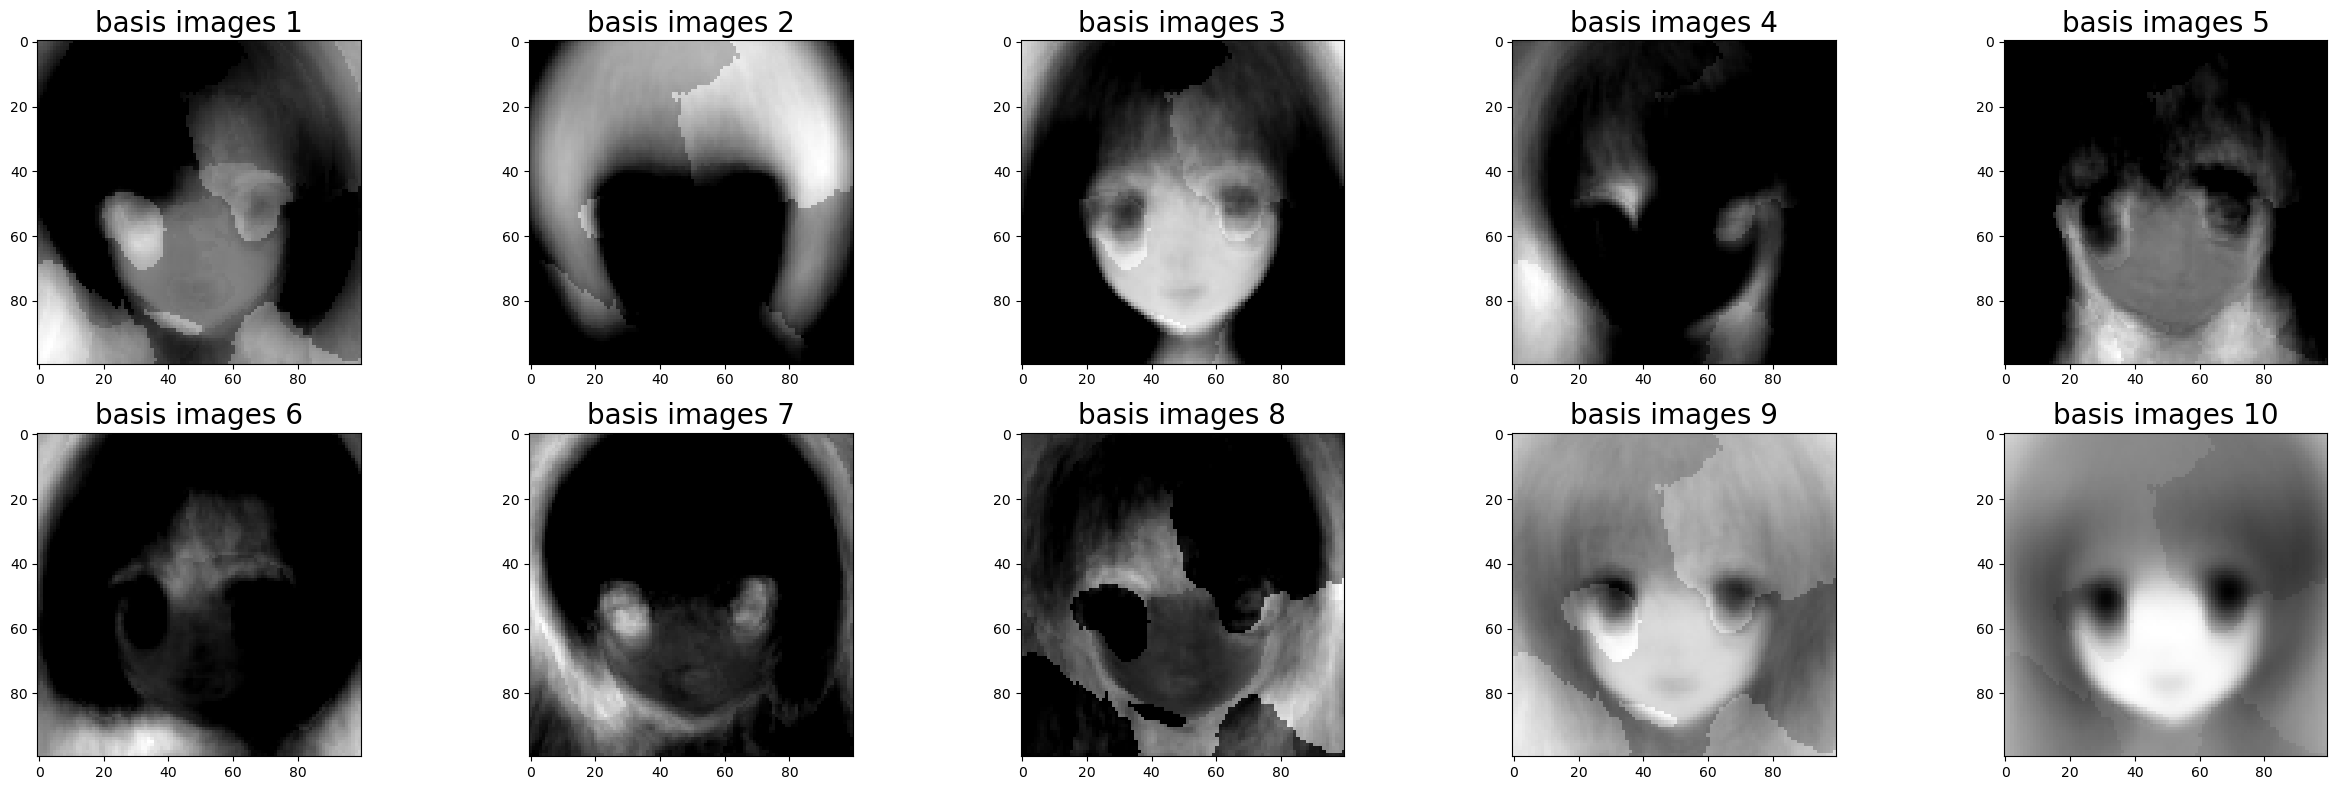

In [ ]:
plt.figure(figsize=(25, 8))

for i, h in enumerate(H):
    plt.subplot(2, 5, i + 1)
    reshape_row(h)
    plt.title("basis images {}".format(str(i + 1)), fontsize=20)

plt.tight_layout()

Use the fitted **`nmf_estimator`** and its **`transform`** method to obtain the encodings for all images.


In [ ]:
W = nmf_estimator.transform(X)

Each of the 9,000 images now has a 10-dimensional encoding.


In [ ]:
W.shape

(9000, 10)

The encoding shows how strongly each image uses each basis component. Here, we plot the encoding magnitudes for image $i$ across all basis components.


Text(0.5, 1.0, 'encodings for image 1 ')

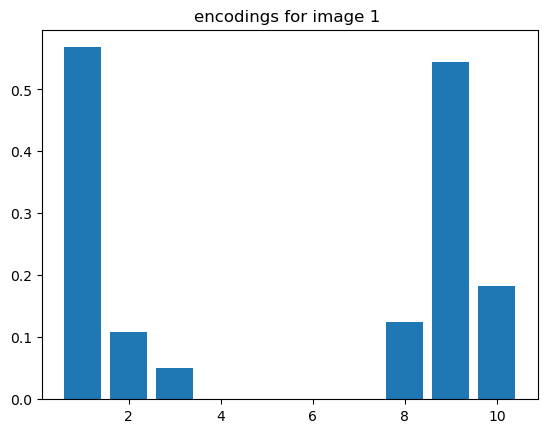

In [ ]:
i = 0
w = W[i, :]

plt.bar([n + 1 for n in range(len(w))], w)
plt.title("encodings for image {} ".format(i + 1))

For image 1, the second encoding has the highest value. When we plot the second basis component, it looks similar to the image. The ninth encoding has a small value, and its basis component looks much less similar to the image.


Text(0.5, 1.0, 'Dissimilar basis 9')

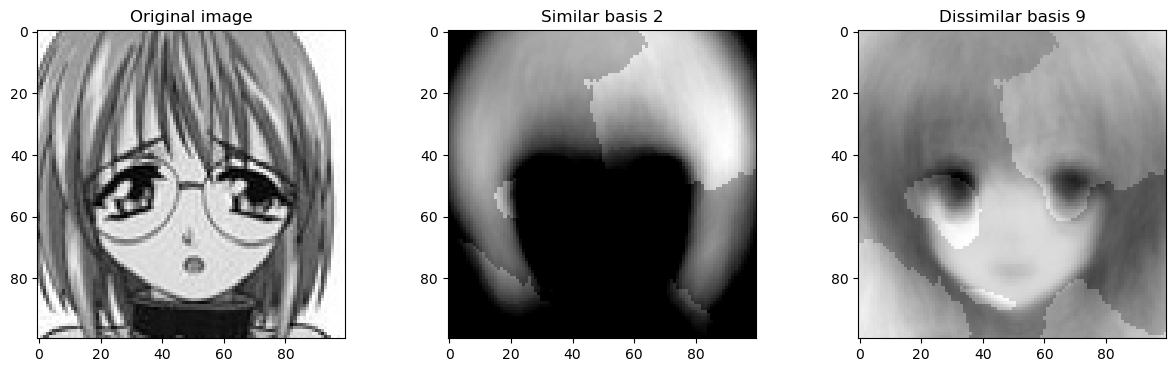

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(131)
reshape_row(X[i, :])
plt.title("Original image")

plt.subplot(132)
reshape_row(H[1, :])
plt.title("Similar basis 2")

plt.subplot(133)
reshape_row(H[8, :])
plt.title("Dissimilar basis 9")

### **Reconstructing Images Using `inverse_transform`**

We can evaluate how well the NMF model reconstructs the original images when the number of latent components ($r$) is limited.

To reconstruct, or "decompress," the data, we multiply the weight matrix $\mathbf{W}$ by the components matrix $\mathbf{H}$. This creates an approximation of the original data matrix:

$$\mathbf{\hat{X}} = \mathbf{W}\mathbf{H}$$

In `scikit-learn`, this reconstruction is performed with **`model.inverse_transform(W)`**:

* **`model.transform(X)`** compresses the high-dimensional data $\mathbf{X}$ from $10,000$ features down to a low-dimensional weight matrix $\mathbf{W}$ with $r$ features.
* **`model.inverse_transform(W)`** reconstructs the data by multiplying the weights $\mathbf{W}$ by the learned basis features $\mathbf{H}$. The result is $\mathbf{\hat{X}}$, a full image-vector approximation of $\mathbf{X}$.

By comparing $\mathbf{\hat{X}}$ with the original matrix $\mathbf{X}$, we can see how much image detail the model kept and how much was lost during dimensionality reduction.

Below, we visualize original images next to their `inverse_transform` approximations:

* **Top rows (Original):** The original high-dimensional images from the dataset.
* **Bottom rows (Reconstructed):** The low-rank approximations generated by `model.inverse_transform(W)`.


Use **`inverse_transform`** to compute $\mathbf{\hat{X}}$, the approximation of $\mathbf{X}$.


In [ ]:
Xhat = nmf_estimator.inverse_transform(W)

Each row of $\mathbf{\hat{X}}$ corresponds to one image. We can reshape each row back into image form and plot the approximations.


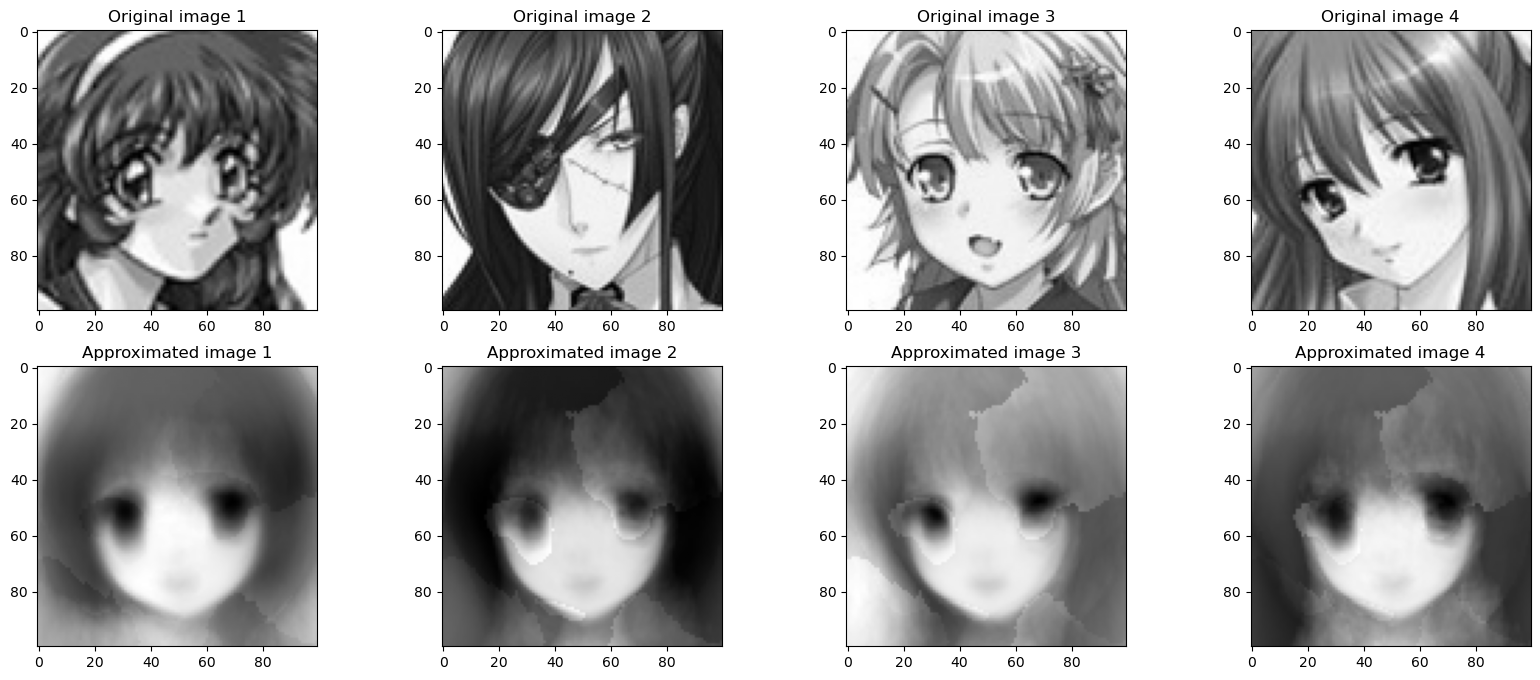

In [ ]:
plt.figure(figsize=(20, 8))

for i in range(1, 5):
    plt.subplot(2, 4, i)
    reshape_row(X[i])
    plt.title(f"Original image {i}")

    plt.subplot(2, 4, i + 4)
    reshape_row(Xhat[i])
    plt.title(f"Approximated image {i}")

1. **Loss of fine detail:** Because the images are forced into a much lower rank ($r \ll D$), the reconstructed images look blurrier. Fine details, such as sharp outlines, hair strands, and subtle textures, are smoothed out or lost.
2. **Retention of core structure:** Even with the blur, the model captures the main global features, such as face shape, major shading regions, and the positions of important facial features like eyes and mouths.
3. **Compression trade-off:** This example shows the main trade-off in dimensionality reduction: we gain strong compression and better interpretability, but we lose exact visual detail.


**Alternative approach:** We can verify that scikit-learn's **`inverse_transform`** method performs the following matrix operation.


In [ ]:
Xhat_M = W @ H

The results are quantitatively identical for the first 10 grayscale values of the first image.


In [ ]:
Xhat[0, :10], Xhat_M[0, :10]

(array([188.06959486, 184.29795402, 183.23174985, 181.45299868,
        176.7213624 , 170.90916687, 168.04222346, 163.19518707,
        158.32928912, 157.09259044]),
 array([188.06959486, 184.29795402, 183.23174985, 181.45299868,
        176.7213624 , 170.90916687, 168.04222346, 163.19518707,
        158.32928912, 157.09259044]))

They are also qualitatively, or visually, identical for images 2 through 5 in the dataset.


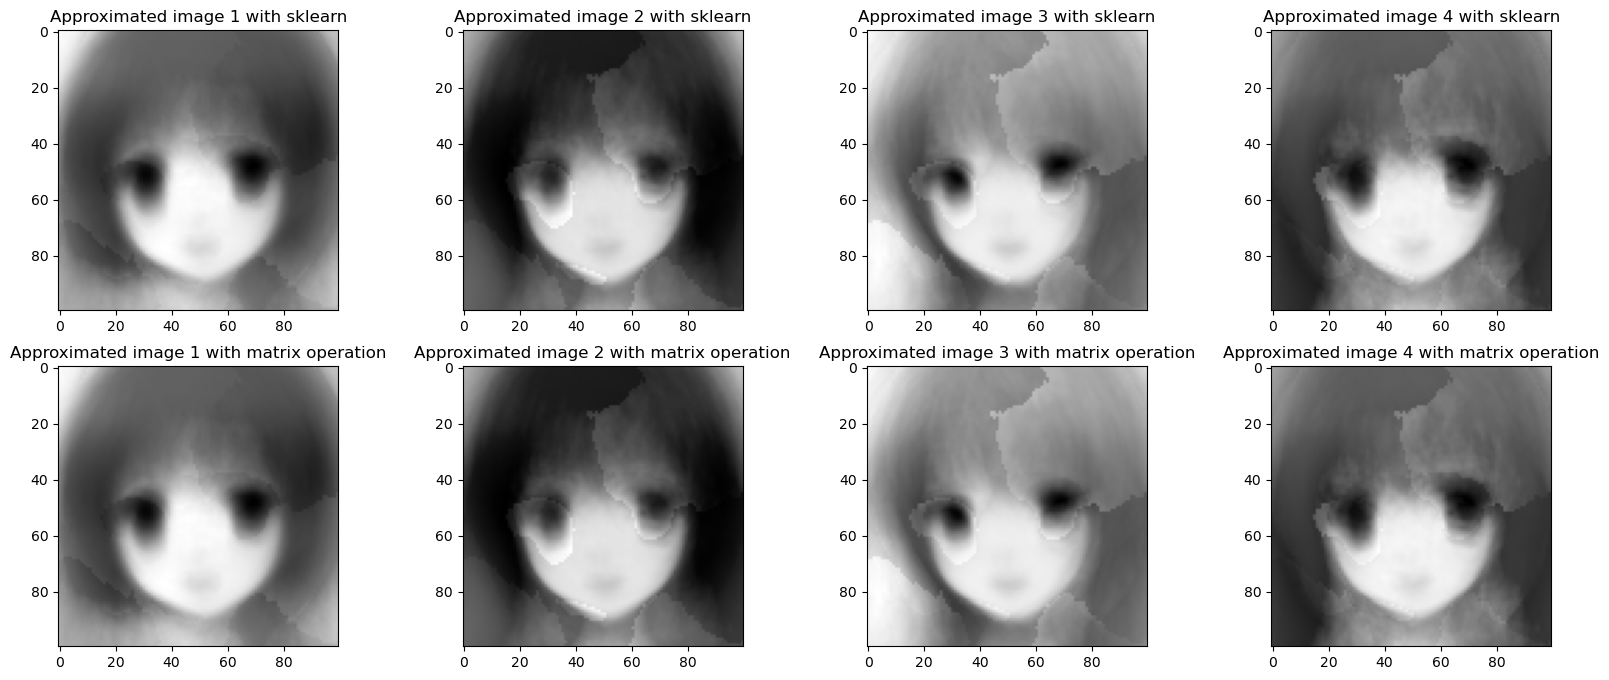

In [ ]:
plt.figure(figsize=(20, 8))

for i in range(1, 5):
    plt.subplot(2, 4, i)
    reshape_row(Xhat[i])
    plt.title(f"Approximated image {i} with sklearn")

    plt.subplot(2, 4, i + 4)
    reshape_row(Xhat_M[i])
    plt.title(f"Approximated image {i} with matrix operation")

We can reconstruct an image by adding one component multiplied by its encoding at a time. In the following code, each added component makes the image look more like its final approximation.


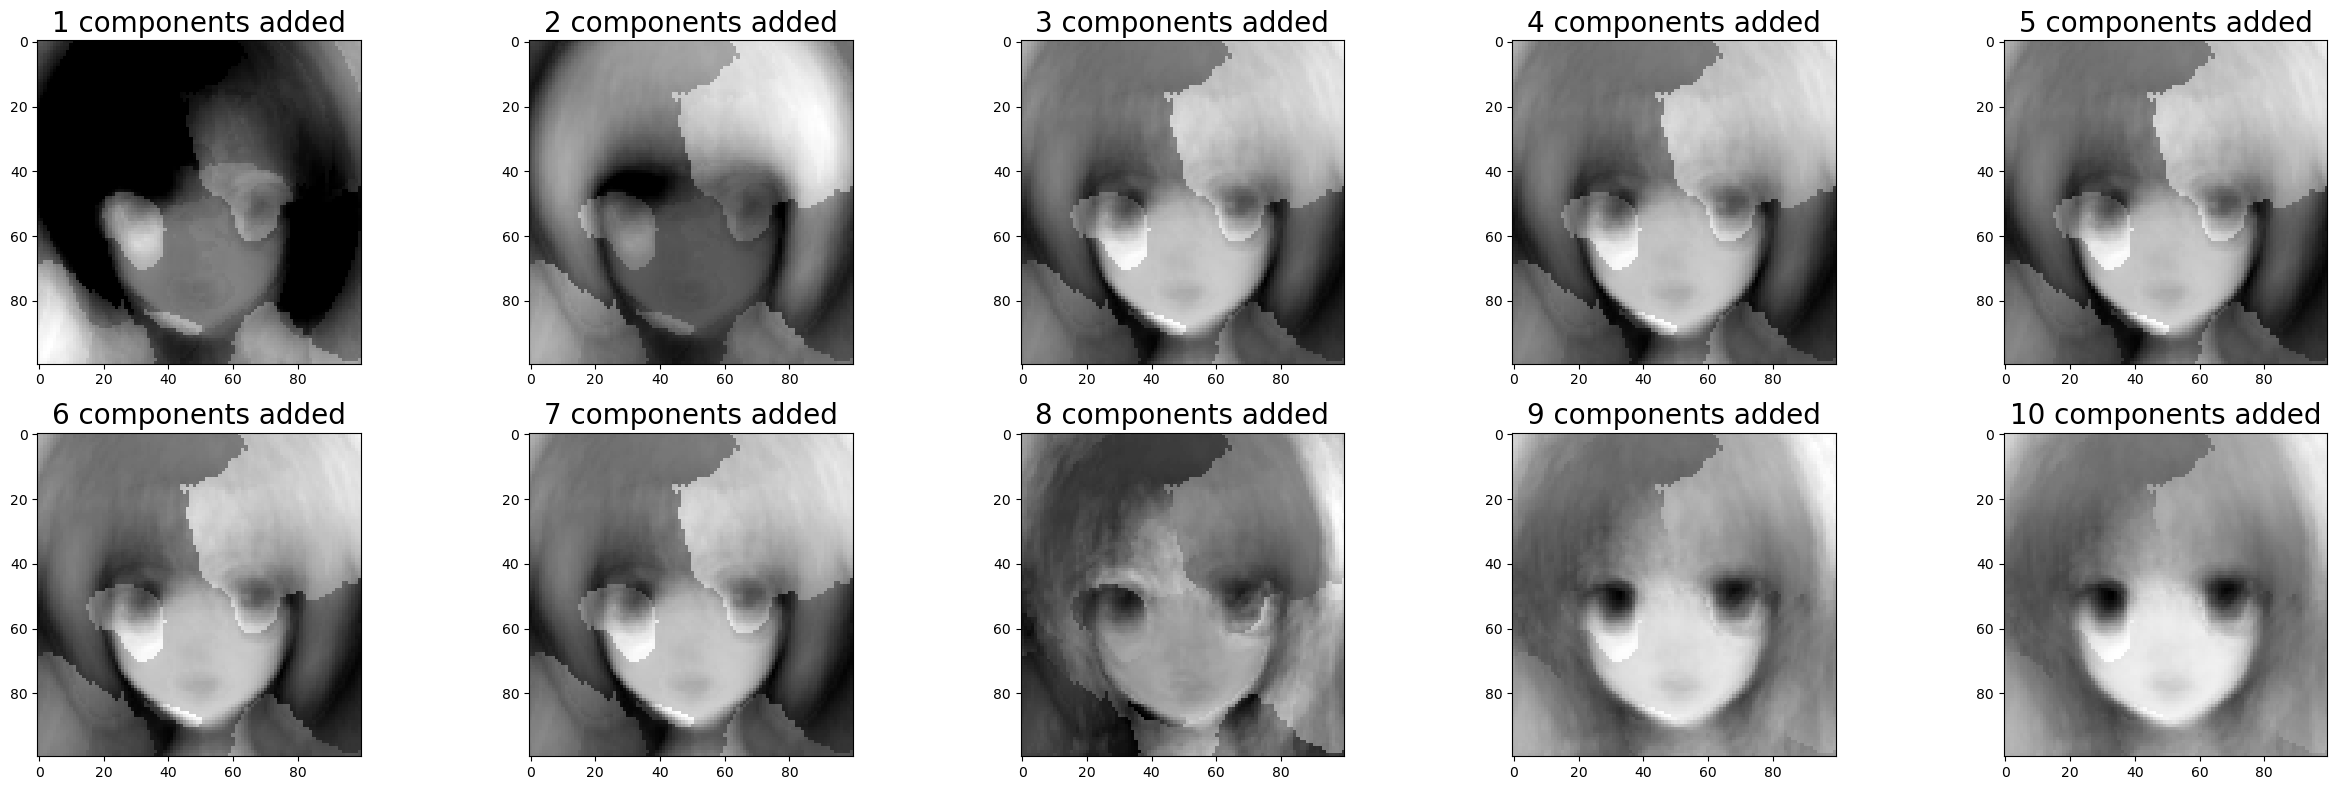

In [ ]:
# initialize an image array with 10000 zeros which will be reshaped as 100x100
image = np.zeros((1, 10000))

plt.figure(figsize=(25, 8))
for i, (w_, h) in enumerate(zip(w, H)):

    # w is the encoding vector of the first image in X
    # reconstruction of the image is a linear combination of H
    plt.subplot(2, 5, i + 1)
    image += w_ * h
    reshape_row(image)
    plt.title(f"{i+1} components added", fontsize=20)
plt.tight_layout()

## **Image Retrieval System**


In this final phase, we build an **image retrieval system** to identify possible copyright infringements. The system processes a new batch of images, called **query images** ($\mathbf{X}_q$), and finds the closest match for each query image in the existing **database images** ($\mathbf{X}$).

Instead of comparing raw pixels directly, the system uses the NMF model to compare images in a compressed, low-dimensional latent feature space.

### **1. Core Concept: Latent Space Matching**

When a new query image enters the system, it goes through a three-step matching pipeline:

1. **Feature extraction (`transform`):** The pre-trained NMF model compresses the query image matrix $\mathbf{X}_q$ into a low-dimensional weight matrix $\mathbf{W}_q$. These weights represent the image's core visual building blocks, such as eye shapes or hair outlines.
2. **Distance calculation:** The system compares the query weights $\mathbf{W}_q$ with the database weights $\mathbf{W}$ using a distance metric, such as Euclidean distance or cosine distance.
3. **Retrieval:** The database image with the smallest distance score is returned as the closest visual match.

### **2. Understanding the Distance Matrix**

To compute matches at scale, the system builds a **distance matrix** ($\mathbf{D}$). If the database contains $9,000$ images and the query batch contains $1,000$ images, $\mathbf{D}$ has shape $(9,000, 1,000)$:

$$\mathbf{D} = \begin{bmatrix} 
d_{1,1} & d_{1,2} & \cdots & d_{1,1000} \\nd_{2,1} & d_{2,2} & \cdots & d_{2,1000} \\n\vdots & \vdots & \ddots & \vdots \\nd_{9000,1} & d_{9000,2} & \cdots & d_{9000,1000}
\end{bmatrix}$$

* **Rows ($i$):** Database images, indexed from $1$ to $9,000$.
* **Columns ($j$):** Query images, indexed from $1$ to $1,000$.
* **Value ($d_{i,j}$):** Distance between database image $i$ and query image $j$. **A lower value means the two faces look more similar.**


An image retrieval system is used to browse, search, and retrieve images from a large database. In this section, we create an image retrieval system that finds similar cartoon characters for copyright review.

The query dataset contains 1,000 images. If these images are similar to images in the original dataset, they may require further review for possible copyright infringement. We load the query dataset into `X_q`, where each row is a flattened $100 \times 100$ image.


In [ ]:
X_q = get_data_matrix(test=True, Length=100, Width=100, mypath="images")
X_q.shape

test data
1000


(1000, 10000)

The next code cell transforms the query images into NMF encodings. These encodings retain much of the important visual information while reducing factors such as noise, rotation, and scale differences. The resulting matrix, `W_q`, is much smaller than the original image matrix, so distance calculations are faster. We will use `W_q` to find similar images.


In [ ]:
W_q = nmf_estimator.transform(X_q)
W_q.shape

(1000, 10)


The distance matrix $D$ contains pairwise distances between the original dataset and the query dataset. We will use cosine distance, which is based on cosine similarity. For two vectors $x$ and $x'$, cosine distance is defined as:

$$1 - \frac{x' x^T}{\|x'\| \|x\|}$$


Consider the following example, where each image is represented as a 2D vector. The original dataset is shown in yellow, and the query dataset is shown in blue. In this example, image $h_2$ is closest to $h_{2q}$, and image $h_3$ is closest to $h_{1q}$.



<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/images/NNMF_vectors.png" width="500" alt="https://pxhere.com/en/photo/1536663">


The resulting distance matrix is shown below. Each row represents one image from the original dataset, and each column represents one image from the query dataset. Each value is the distance between that original image and that query image. Smaller values indicate more similar images. For example, image $h_2$ in the second row is closest to $h_{2q}$ in the second column.


<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/images/Sim_Matix.png" width="500" alt="https://pxhere.com/en/photo/1536663">


We will use the `pairwise_distances` function from scikit-learn. This function accepts a vector array or a precomputed distance matrix. If the input is a vector array, the function computes and returns the pairwise distance matrix.


In [ ]:
from sklearn.metrics import pairwise_distances

In [ ]:
# calculates the pairwise distance between the NNMF encoded version of
# the original dataset W and the encoded version of the query dataset W_q
D = pairwise_distances(W, W_q, metric="cosine")

The number of rows corresponds to the number of samples in the original dataset. The number of columns corresponds to the number of samples in the query dataset.


In [ ]:
D.shape

(9000, 1000)

#### **Finding the Best Match Using `np.argmin`**

To find the best match for each database image, we search across each row and find the query image with the smallest distance. Because each image in the original dataset corresponds to one row in the distance matrix, the column index with the smallest value gives the closest query image.


In [ ]:
similar_index = np.argmin(D, axis=1)

We also find the corresponding distance value.


In [ ]:
similar_distance = np.min(D, axis=1)

We plot the distance values in a histogram. The values range from 0 to approximately 0.06.


Text(0.5, 1.0, 'Distance values')

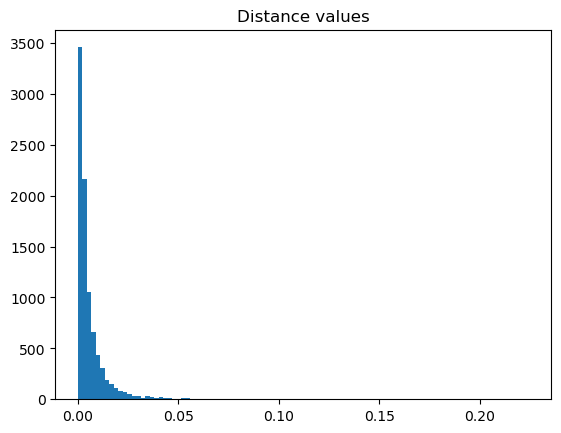

In [ ]:
plt.hist(similar_distance, bins=100)
plt.title("Distance values")

If we use a maximum distance threshold of $1.0 \times 10^{-5}$ for the first five samples, the matched images are identical.


In [ ]:
dataset_index, query_index = threshold(similar_distance, max_=0.00001, min_=0)

In [ ]:
dataset_index.shape, query_index.shape

((36,), (36,))

In [ ]:
dataset_index[:10]

array([ 451,  626,  686, 1030, 1434, 1557, 2133, 2397, 2525, 2988])

In [ ]:
query_index[:10]

array([856, 783, 173, 856, 292, 812, 856, 627, 320, 285])

If we instead use a threshold between $5.0 \times 10^{-3}$ and $1.0 \times 10^{-2}$ and plot the first five samples, many of the query images are visibly different from the originals.


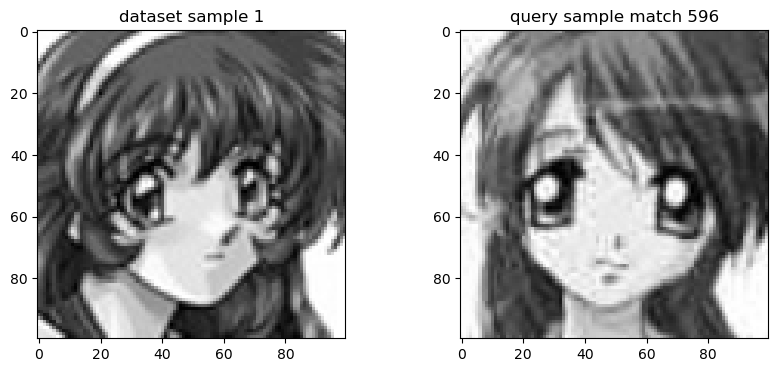

-----------------------------------------------------


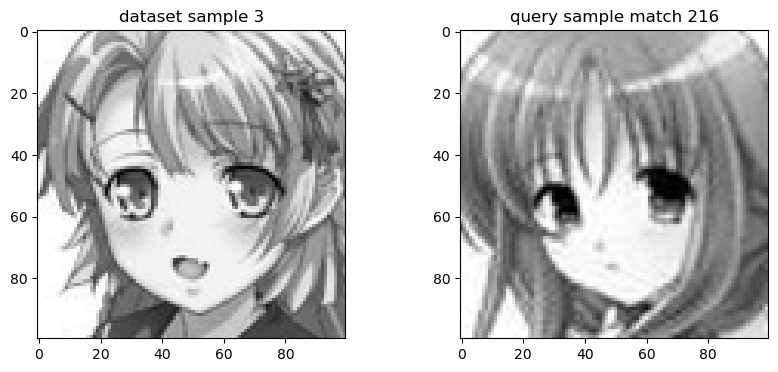

-----------------------------------------------------


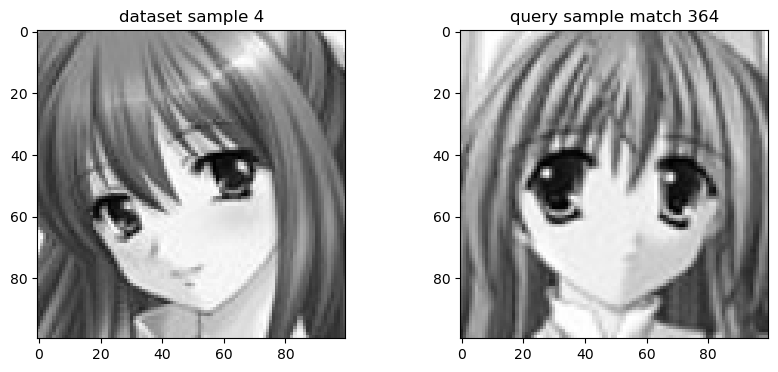

-----------------------------------------------------


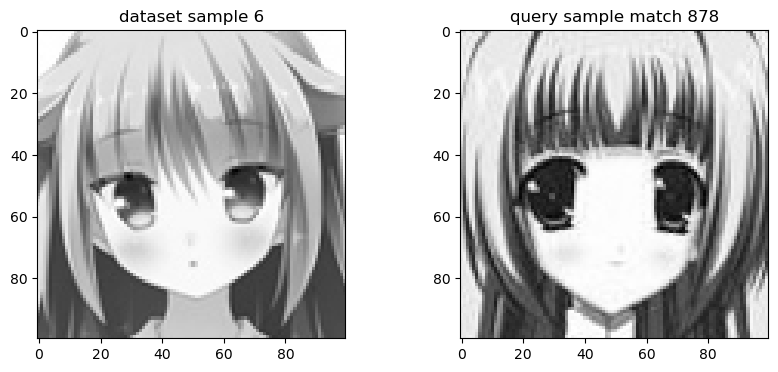

-----------------------------------------------------


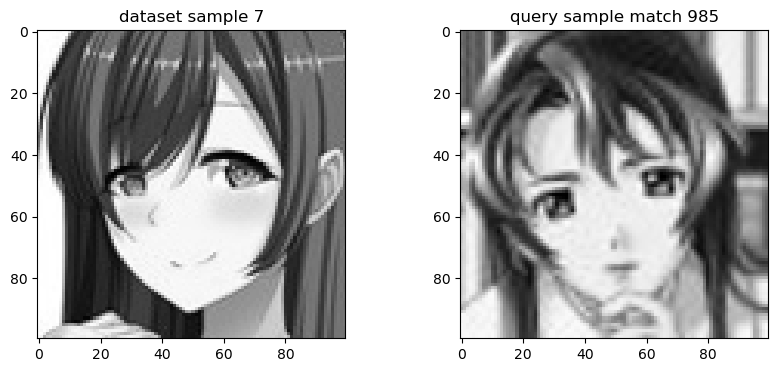

-----------------------------------------------------


In [ ]:
dataset_index, query_index = threshold(
    similar_distance, max_=0.005, min_=0.00001
)
plot_data_query(dataset_index, query_index, 5)

## **Exercises**


In this exercise, you will apply NMF to the [face images](https://scikit-learn.org/stable/auto_examples/decomposition/plot_faces_decomposition.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01#sphx-glr-auto-examples-decomposition-plot-faces-decomposition-py) from scikit-learn. You will then perform an image retrieval task to find pairs of similar faces.


In [ ]:
from sklearn.datasets import fetch_olivetti_faces

rng = RandomState(0)
data = fetch_olivetti_faces(shuffle=True, random_state=rng)
X = data.images

In [ ]:
image_shape = (64, 64)


def plot_faces(title, images, n_col, n_row, cmap=plt.cm.gray):
    fig, axs = plt.subplots(
        nrows=n_row,
        ncols=n_col,
        figsize=(2.0 * n_col, 2.3 * n_row),
        facecolor="white",
        constrained_layout=True,
    )

    fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.02, hspace=0, wspace=0)
    fig.set_edgecolor("black")
    fig.suptitle(title, size=16)
    for ax, vec in zip(axs.flat, images):
        vmax = max(vec.max(), -vec.min())
        im = ax.imshow(
            vec.reshape(image_shape),
            cmap=cmap,
            interpolation="nearest",
            vmin=-vmax,
            vmax=vmax,
        )
        ax.axis("off")

    fig.colorbar(
        im, ax=axs, orientation="horizontal", shrink=0.99, aspect=40, pad=0.01
    )
    plt.show()

Use the **`plot_faces`** function to plot the first six faces in the dataset.


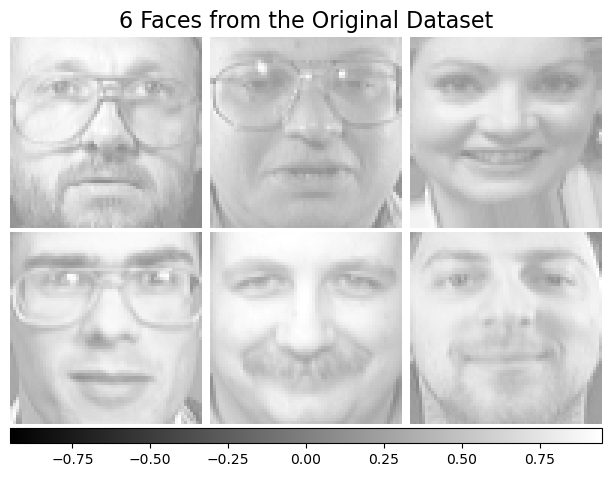

In [ ]:
plot_faces("6 Faces from the Original Dataset", X[:6], 3, 2)

### **Exercise 1**

The face image dataset has 400 images. Split it into two parts:

- **`X_r`**: the first 300 images. This is the original image database.
- **`X_q`**: the remaining 100 images. These are the query images we want to match.

Each image is originally a $64 \times 64$ matrix. Reshape each image into one row with $64 \times 64 = 4096$ pixel features.

Fit the NMF model on **`X_r`**, then use the same fitted model to transform **`X_q`**. This keeps both datasets in the same NMF feature space.


In [ ]:
X_r = X[:300].reshape((300, 64 * 64))
X_q = X[300:].reshape((100, 64 * 64))

nmf = NMF(n_components=10, tol=5e-3, max_iter=2000)
X_r_W = nmf.fit_transform(X_r)
X_q_W = nmf.transform(X_q)

#### **Exercise 1 Check: Inspecting the Learned NMF Components**

After fitting NMF, the model stores the learned basis components in **`nmf.components_`**. Each component is a learned face-like pattern. Plotting these components helps us understand what the model learned before we use the encodings for image retrieval.


In [ ]:
H = nmf.components_
plot_faces("Basis from dataset", H, 3, 2)

#### **Reconstructing Query Faces with `inverse_transform`**

The query images are encoded as **`X_q_W`**. To check whether these encodings still contain useful visual information, we reconstruct the first six query faces.

The method **`inverse_transform`** multiplies the query encodings by the learned basis components and returns approximate image vectors. The reconstructed faces will not be perfect, but they should keep the main face structure.


In [ ]:
w6 = X_q_W[:6, :]  # first 6 query encodings

X_hat = nmf.inverse_transform(w6)
plot_faces("6 Reconstructed faces using inverse_transform", X_hat, 3, 2)

#### **Verifying the Reconstruction with Matrix Multiplication**

NMF reconstruction follows the formula:

$$\mathbf{\hat{X}} = \mathbf{W}\mathbf{H}$$

Here, **`w6`** contains the first six query encodings, and **`H`** contains the learned basis components. Multiplying **`w6 @ H`** should give the same type of reconstruction as **`inverse_transform`**.


In [ ]:
X_hat_M = w6 @ H
plot_faces("6 Reconstructed faces using matrix operations", X_hat_M, 3, 2)
print("-------------------------------------------------------")
plot_faces("6 Reconstructed faces using inverse_transform", X_hat, 3, 2)

### **Exercise 2**

Compare the NMF encodings from the original dataset and the query dataset.

Use `pairwise_distances` with cosine distance. Store the result in **`D`**.

The matrix **`D`** has one row for each original image and one column for each query image. A smaller value means the two images are more similar.


In [ ]:
from sklearn.metrics import pairwise_distances

D = pairwise_distances(X_r_W, X_q_W, metric="cosine")

### **Exercise 3**

For each original image, find the query image with the smallest distance.

- **`similar_index`** stores the index of the closest query image.
- **`similar_distance`** stores the distance value for that closest match.


In [ ]:
similar_index = np.argmin(D, axis=1)
similar_distance = np.min(D, axis=1)

### **Exercise 4**

Use the `threshold` function to keep only matches whose distances are within the selected range. Then use `plot_data_query` to display the first five matched image pairs.

The plotting helper uses the global image size values, so set **`Length = 64`** and **`Width = 64`** before plotting these face images.


In [ ]:
Length = 64
Width = 64

o_index, q_index = threshold(similar_distance, max_=0.1, min_=0)
plot_data_query(o_index, q_index, 5)

## **Authors**


<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01">Joseph Santarcangelo</a> has a Ph.D. in Electrical Engineering. His research focused on using machine learning, signal processing, and computer vision to study how videos affect human cognition. Joseph has worked for IBM since completing his Ph.D.

[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) is a Data Science intern at IBM Skills Network and is entering level-5 study in the Mathematics and Statistics undergraduate co-op program at McMaster University.

Su Wu


## **Change Log**


| Date (YYYY-MM-DD) | Version | Changed By  | Change Description             |
| ----------------- | ------- | ----------- | ------------------------------ |
| 2022-03-25        | 0.1     | Joseph S.   | Updated all content            |
| 2022-04-26        | 0.1     | Svitlana K. | Corrected minor grammar errors |
| 2022-06-06        | 0.1     | Roxanne Li  | Review and edit content        |
|2026-05-17 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|